<a href="https://colab.research.google.com/github/Moozzii/machine_learning/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, KBinsDiscretizer, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import RidgeCV

In [64]:
df = pd.read_csv('train.csv')

In [65]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [66]:
df.drop(columns=['YrSold', 'Utilities', 'Condition2', 'MiscFeature', 'Street', 'Id', 'MSSubClass', 'PoolQC', 'Fence', 'MasVnrType', 'Alley', 'FireplaceQu'], inplace=True)

In [67]:
df['LotFrontage'] = np.where(df['LotFrontage'].isna(), df['LotFrontage'].mod, df['LotFrontage'])

In [68]:
df['MasVnrArea'] = np.where(df['MasVnrArea'].isna(), df['MasVnrArea'].mean(), df['MasVnrArea'])

In [69]:
df[['GarageCond', 'GarageQual', 'GarageFinish', 'GarageType', 'Electrical', 'BsmtFinType2', 'BsmtFinType1', 'BsmtFinType1', 'BsmtExposure', 'BsmtCond', 'BsmtQual', 'MasVnrArea']] = np.where(df[['GarageCond', 'GarageQual', 'GarageFinish', 'GarageType', 'Electrical', 'BsmtFinType2', 'BsmtFinType1', 'BsmtFinType1', 'BsmtExposure', 'BsmtCond', 'BsmtQual', 'MasVnrArea']].isna(), df[['GarageCond', 'GarageQual', 'GarageFinish', 'GarageType', 'Electrical', 'BsmtFinType2', 'BsmtFinType1', 'BsmtFinType1', 'BsmtExposure', 'BsmtCond', 'BsmtQual', 'MasVnrArea']].mod, df[['GarageCond', 'GarageQual', 'GarageFinish', 'GarageType', 'Electrical', 'BsmtFinType2', 'BsmtFinType1', 'BsmtFinType1', 'BsmtExposure', 'BsmtCond', 'BsmtQual', 'MasVnrArea']])

In [70]:
df['GarageYrBlt'] = np.where(df['GarageYrBlt'].isna(), df['GarageYrBlt'].mean(), df['GarageYrBlt'])

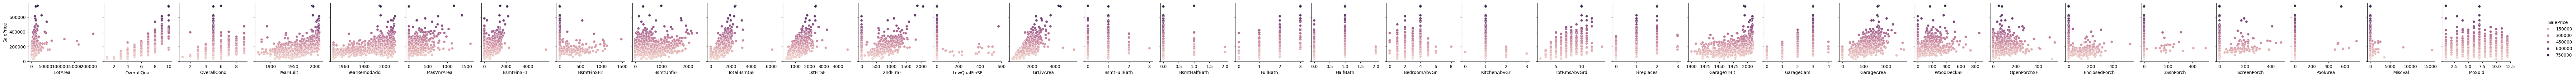

In [71]:
import seaborn as sns

sns.pairplot(data=df, hue="SalePrice", y_vars=["SalePrice"])
plt.show()


### Start with transformations and remove/deal with outliers

In [72]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='SalePrice'),  df['SalePrice'], random_state=42, test_size=0.2)

In [73]:
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'GarageQual', 'GarageCond']

all_objects = ['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood',
               'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
               'Exterior2nd', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
               'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish',
               'PavedDrive', 'SaleType', 'SaleCondition']

nominal_cols = [col for col in all_objects if col not in ordinal_cols]

ordinal_transformer = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
)

onehot_transformer = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

preprocessor = make_column_transformer(
    (FunctionTransformer(np.log1p, validate=True,feature_names_out='one-to-one'), ['LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', '2ndFlrSF', 'LowQualFinSF', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch']),
    (StandardScaler(), ['LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch']),
    (KBinsDiscretizer(n_bins=2, encode='ordinal', strategy='quantile'), ['MiscVal', 'PoolArea', '3SsnPorch']),
    (ordinal_transformer, ordinal_cols),
    (onehot_transformer, nominal_cols),
    remainder='drop'
)


In [74]:

all_cols_to_check = ordinal_cols + nominal_cols + ['LotFrontage']

for col in all_cols_to_check:
    if col in X_train.columns:

        X_train[col] = X_train[col].apply(lambda x: None if callable(x) else x)

        if col in ['LotFrontage']:
            X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        else:
            X_train[col] = X_train[col].astype(str).replace('None', np.nan)

for col in all_cols_to_check:
    if col in X_test.columns:
        X_test[col] = X_test[col].apply(lambda x: None if callable(x) else x)
        if col in ['LotFrontage']:
            X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
        else:
            X_test[col] = X_test[col].astype(str).replace('None', np.nan)

In [75]:
base_model = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0])

modified_model = TransformedTargetRegressor(
    regressor=base_model,
    func=np.log1p,
    inverse_func=np.expm1
)

final_pipeline = make_pipeline(preprocessor, modified_model)
final_pipeline.fit(X_train, y_train)

print("Final Optimized R2 Score:", final_pipeline.score(X_test, y_test))


Final Optimized R2 Score: 0.9054783472909743


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
